In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [4]:
print(data.target_names)

['malignant' 'benign']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [7]:
y_pred = model.predict(X_test_scaled)

In [8]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [9]:
y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:10])

[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]
 [1.00000000e+00 9.48087773e-11]
 [9.99999998e-01 1.53672648e-09]
 [9.65096937e-01 3.49030633e-02]
 [3.79342140e-01 6.20657860e-01]
 [7.59402734e-04 9.99240597e-01]]


In [10]:
threshold = 0.7

y_pred_custom = (y_prob[:, 1] >= threshold).astype(int)

In [11]:
threshold = 0.3

y_pred_custom = (y_prob[:, 1] >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1:", f1_score(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Accuracy: 0.9824561403508771
Precision: 0.9726027397260274
Recall: 1.0
F1: 0.9861111111111112
[[41  2]
 [ 0 71]]


In [12]:
print(y_prob[:, 1])

[8.86409750e-01 9.00936206e-06 3.07909541e-03 9.99489866e-01
 9.99939361e-01 9.48087773e-11 1.53672648e-09 3.49030633e-02
 6.20657860e-01 9.99240597e-01 9.50128217e-01 1.24071210e-02
 9.93926181e-01 1.43930883e-01 9.98378244e-01 7.40182295e-04
 9.98147541e-01 9.99988834e-01 9.99999182e-01 1.11701472e-06
 9.15836610e-01 9.90252217e-01 4.33732393e-09 9.99921081e-01
 9.98861257e-01 9.99415413e-01 9.98925555e-01 9.94024817e-01
 9.97146883e-01 8.18296669e-06 9.99482590e-01 9.99851240e-01
 9.97839056e-01 9.94505862e-01 9.99859294e-01 9.97576657e-01
 5.75840151e-02 9.97101296e-01 8.87859084e-05 9.51863624e-01
 9.99928757e-01 4.06608387e-04 9.97533594e-01 9.99036115e-01
 9.80010795e-01 9.28445266e-01 9.99601428e-01 9.99509374e-01
 9.69530199e-01 9.99385984e-01 1.20346382e-04 5.31315374e-08
 6.91788480e-01 9.86770623e-01 9.99972637e-01 9.90454756e-01
 9.99887121e-01 7.32867884e-12 1.64426910e-01 9.99860760e-01
 9.94986396e-01 4.49298134e-07 1.41043187e-09 9.68893953e-01
 9.99170906e-01 8.702007

In [13]:
for threshold in [0.3, 0.5, 0.7]:

    y_pred_custom = (y_prob[:, 1] >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print("Accuracy:", accuracy_score(y_test, y_pred_custom))
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall:", recall_score(y_test, y_pred_custom))
    print("F1:", f1_score(y_test, y_pred_custom))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_custom))


Threshold: 0.3
Accuracy: 0.9824561403508771
Precision: 0.9726027397260274
Recall: 1.0
F1: 0.9861111111111112
Confusion Matrix:
[[41  2]
 [ 0 71]]

Threshold: 0.5
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1: 0.9790209790209791
Confusion Matrix:
[[41  2]
 [ 1 70]]

Threshold: 0.7
Accuracy: 0.956140350877193
Precision: 0.9852941176470589
Recall: 0.9436619718309859
F1: 0.9640287769784173
Confusion Matrix:
[[42  1]
 [ 4 67]]


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

In [15]:
auc = roc_auc_score(y_test, y_prob[:, 1])

print("AUC:", auc)

AUC: 0.99737962659679


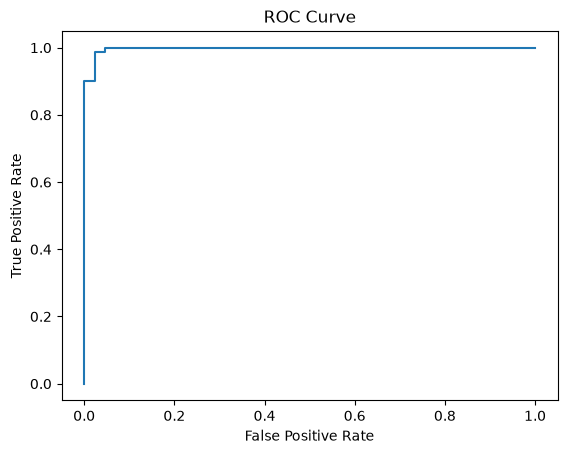

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()